<a href="https://colab.research.google.com/github/rizzo-so/Checkpoint_01_2SEM/blob/main/CHECKPOINT_01_1EMA_2SEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação Prática — Listas, Tuplas e Dicionários com APIs

**Curso:** Engenharia Mecatrônica — 1º ano  
**Disciplina:** Computational Thinking of Engineering  
**Duração:** 1 hora  
**Valor:** 10,0 pontos  

## Orientações

Nesta avaliação, você utilizará dados obtidos de duas APIs públicas para resolver situações relacionadas a sistemas mecatrônicos.

- **AwesomeAPI:** cotações de moedas;
- **OpenWeather:** dados meteorológicos.

A parte responsável pela conexão HTTP já está pronta. **Você não será avaliado pelo uso da biblioteca `requests`.**

Sua tarefa começa a partir dos dados retornados pelas APIs. Você deverá:

- acessar dados em estruturas retornadas em JSON;
- criar e manipular **listas**;
- criar e acessar **tuplas**;
- criar, consultar e atualizar **dicionários**;
- combinar essas estruturas para resolver as situações propostas;
- utilizar **Secrets do Google Colab** para armazenar uma chave de API.

### Regras

- Execute as células de conexão antes de iniciar as questões.
- Não altere o código das células marcadas como **NÃO ALTERE**.
- Nas questões, não utilize respostas fixas.
- Seu código deve funcionar mesmo que os valores retornados pelas APIs mudem.


---
# Conexão com as APIs

As próximas células realizam as requisições e disponibilizam os dados retornados.

Para acessar a OpenWeather, a chave da API deve ser armazenada nos **Secrets do Google Colab** com o nome:

`OPENWEATHER_API_KEY`

No Colab, abra **Secrets** na barra lateral, crie esse segredo e habilite o acesso ao notebook.

A organização dos dados retornados em listas, tuplas e dicionários faz parte da avaliação.


In [9]:
import requests
from google.colab import userdata

In [10]:
url_cambio = "https://economia.awesomeapi.com.br/json/last/USD-BRL,EUR-BRL,GBP-BRL"

try:
    resposta = requests.get(url_cambio, timeout=15)
    resposta.raise_for_status()
    dados_cambio_api = resposta.json()
except requests.RequestException:
    dados_cambio_api = {
        "USDBRL": {
            "code": "USD",
            "codein": "BRL",
            "name": "Dólar Americano/Real Brasileiro",
            "bid": "5.42",
            "ask": "5.44"
        },
        "EURBRL": {
            "code": "EUR",
            "codein": "BRL",
            "name": "Euro/Real Brasileiro",
            "bid": "6.31",
            "ask": "6.34"
        },
        "GBPBRL": {
            "code": "GBP",
            "codein": "BRL",
            "name": "Libra Esterlina/Real Brasileiro",
            "bid": "7.29",
            "ask": "7.33"
        }
    }

dados_cambio_api


{'USDBRL': {'code': 'USD',
  'codein': 'BRL',
  'name': 'Dólar Americano/Real Brasileiro',
  'bid': '5.42',
  'ask': '5.44'},
 'EURBRL': {'code': 'EUR',
  'codein': 'BRL',
  'name': 'Euro/Real Brasileiro',
  'bid': '6.31',
  'ask': '6.34'},
 'GBPBRL': {'code': 'GBP',
  'codein': 'BRL',
  'name': 'Libra Esterlina/Real Brasileiro',
  'bid': '7.29',
  'ask': '7.33'}}

In [11]:
OPENWEATHER_API_KEY = userdata.get("OPENWEATHER_API_KEY")

locais = [
    ("São Paulo", -23.5505, -46.6333),
    ("Campinas", -22.9056, -47.0608),
    ("Santos", -23.9608, -46.3336),
    ("São José dos Campos", -23.2237, -45.9009)
]

dados_clima_api = []

for cidade, latitude, longitude in locais:
    url = "https://api.openweathermap.org/data/2.5/weather"

    parametros = {
        "lat": latitude,
        "lon": longitude,
        "appid": OPENWEATHER_API_KEY,
        "units": "metric",
        "lang": "pt_br"
    }

    resposta = requests.get(url, params=parametros, timeout=15)
    resposta.raise_for_status()

    dados = resposta.json()
    dados["_cidade_avaliacao"] = cidade
    dados_clima_api.append(dados)

dados_clima_api


[{'coord': {'lon': -46.6333, 'lat': -23.5505},
  'weather': [{'id': 804,
    'main': 'Clouds',
    'description': 'nublado',
    'icon': '04d'}],
  'base': 'stations',
  'main': {'temp': 15.49,
   'feels_like': 15.34,
   'temp_min': 14.69,
   'temp_max': 16.66,
   'pressure': 1023,
   'humidity': 86,
   'sea_level': 1023,
   'grnd_level': 931},
  'visibility': 10000,
  'wind': {'speed': 3.09, 'deg': 70},
  'clouds': {'all': 100},
  'dt': 1787660594,
  'sys': {'type': 1,
   'id': 8394,
   'country': 'BR',
   'sunrise': 1787649848,
   'sunset': 1787691215},
  'timezone': -10800,
  'id': 3458611,
  'name': 'Liberdade',
  'cod': 200,
  '_cidade_avaliacao': 'São Paulo'},
 {'coord': {'lon': -47.0608, 'lat': -22.9056},
  'weather': [{'id': 804,
    'main': 'Clouds',
    'description': 'nublado',
    'icon': '04d'}],
  'base': 'stations',
  'main': {'temp': 21.78,
   'feels_like': 21.55,
   'temp_min': 21.3,
   'temp_max': 21.86,
   'pressure': 1017,
   'humidity': 59,
   'sea_level': 1017,
  

---
# Situação-problema 1 — Componentes para um protótipo mecatrônico

Uma equipe está desenvolvendo um protótipo de monitoramento industrial e precisa estimar o custo de componentes importados.

A variável `dados_cambio_api` contém o retorno da AwesomeAPI.

Um exemplo simplificado da estrutura retornada é:

```python
{
    "USDBRL": {
        "code": "USD",
        "bid": "...",
        "ask": "..."
    }
}
```

O valor de `ask` representa a cotação de venda que será utilizada nesta avaliação.


## Questão 1 — Tratando os dados de câmbio **(2,0 pontos)**

A partir de `dados_cambio_api`, crie uma variável chamada `cotacoes` contendo uma **lista de tuplas**.

Cada tupla deve possuir:

```text
(moeda, valor_de_venda)
```

Exemplo de estrutura:

```python
[
    ("USD", 0.00),
    ("EUR", 0.00)
]
```

### Requisitos

1. Os valores devem ser extraídos de `dados_cambio_api`.
2. Converta a cotação para `float`.
3. Exiba a lista criada.
4. Determine, percorrendo a estrutura, qual moeda possui a maior cotação de venda.
5. Exiba:

```text
Maior cotação: XXX - R$ 0.00
```

Não copie manualmente os valores retornados pela API.


In [12]:
cotacoes = []

for key, data in dados_cambio_api.items():
    moeda = data['code']
    valor_de_venda = float(data['ask'])
    cotacoes.append((moeda, valor_de_venda))

print("Lista de Cotações:", cotacoes)

maior_cotacao_moeda = ""
maior_cotacao_valor = 0.0

for moeda, valor in cotacoes:
    if valor > maior_cotacao_valor:
        maior_cotacao_valor = valor
        maior_cotacao_moeda = moeda

print(f"Maior cotação: {maior_cotacao_moeda} - R$ {maior_cotacao_valor:.2f}")

Lista de Cotações: [('USD', 5.44), ('EUR', 6.34), ('GBP', 7.33)]
Maior cotação: GBP - R$ 7.33


## Questão 2 — Custo do protótipo **(3,0 pontos)**

A equipe pretende adquirir:

| Componente | Quantidade | Preço unitário | Moeda |
|---|---:|---:|---|
| Sensor de pressão | 4 | 18.50 | USD |
| Módulo de comunicação | 2 | 42.00 | EUR |
| Conector industrial | 6 | 9.80 | GBP |
| Microcontrolador | 3 | 12.90 | USD |

### Parte A

Crie um dicionário chamado `componentes`.

Cada chave deve ser o nome de um componente e cada valor uma tupla:

```text
(quantidade, preço_unitário, moeda)
```

### Parte B

Utilizando `componentes` e a lista `cotacoes` criada na Questão 1:

1. calcule o custo em reais de cada item;
2. armazene os resultados em um dicionário chamado `custos_brl`;
3. calcule o custo total;
4. identifique o componente de maior custo.

Utilize:

```text
custo = quantidade × preço unitário × cotação de venda
```


In [13]:
# Parte A: Criação do dicionário componentes
componentes = {
    "Sensor de pressão": (4, 18.50, "USD"),
    "Módulo de comunicação": (2, 42.00, "EUR"),
    "Conector industrial": (6, 9.80, "GBP"),
    "Microcontrolador": (3, 12.90, "USD")
}

print("Dicionário componentes:", componentes)

# Parte B: Cálculo dos custos em BRL e identificação do componente de maior custo
custos_brl = {}
custo_total = 0.0
maior_custo_componente = ""
valor_maior_custo = 0.0

# Converter cotacoes para um dicionário para facilitar a busca
cotacoes_dict = {moeda: valor for moeda, valor in cotacoes}

for componente_nome, (quantidade, preco_unitario, moeda) in componentes.items():
    if moeda in cotacoes_dict:
        cotacao_venda = cotacoes_dict[moeda]
        custo_item_brl = quantidade * preco_unitario * cotacao_venda
        custos_brl[componente_nome] = custo_item_brl
        custo_total += custo_item_brl

        if custo_item_brl > valor_maior_custo:
            valor_maior_custo = custo_item_brl
            maior_custo_componente = componente_nome
    else:
        print(f"Cotação para {moeda} não encontrada para o componente {componente_nome}")

print("\nDicionário custos_brl:", custos_brl)
print(f"Custo Total do Protótipo: R$ {custo_total:.2f}")
print(f"Componente de Maior Custo: {maior_custo_componente} - R$ {valor_maior_custo:.2f}")

Dicionário componentes: {'Sensor de pressão': (4, 18.5, 'USD'), 'Módulo de comunicação': (2, 42.0, 'EUR'), 'Conector industrial': (6, 9.8, 'GBP'), 'Microcontrolador': (3, 12.9, 'USD')}

Dicionário custos_brl: {'Sensor de pressão': 402.56, 'Módulo de comunicação': 532.56, 'Conector industrial': 431.004, 'Microcontrolador': 210.52800000000002}
Custo Total do Protótipo: R$ 1576.65
Componente de Maior Custo: Módulo de comunicação - R$ 532.56


---
# Situação-problema 2 — Teste de campo

O protótipo deverá ser testado em ambiente externo. Antes do deslocamento, a equipe consulta dados meteorológicos atuais das cidades disponíveis.

A variável `dados_clima_api` contém uma **lista com os JSONs brutos retornados pela OpenWeather**.

Para cada cidade, serão utilizados:

- `["_cidade_avaliacao"]` → nome da cidade;
- `["main"]["temp"]` → temperatura em °C;
- `["main"]["humidity"]` → umidade em %;
- `["wind"]["speed"]` → velocidade do vento em m/s.

Você deverá organizar esses dados em estruturas Python adequadas.


## Questão 3 — Organizando os dados meteorológicos **(2,0 pontos)**

A partir de `dados_clima_api`, crie uma variável chamada `dados_clima` contendo uma **lista de dicionários**.

Cada dicionário deve possuir exatamente:

```python
{
    "cidade": ...,
    "temperatura": ...,
    "umidade": ...,
    "vento": ...
}
```

Depois:

1. exiba `dados_clima`;
2. identifique a cidade com a menor temperatura;
3. identifique a cidade com a maior velocidade do vento;
4. exiba os resultados.

Os dados devem ser extraídos da resposta da OpenWeather.


In [14]:
dados_clima = []

for cidade_data in dados_clima_api:
    cidade = cidade_data["_cidade_avaliacao"]
    temperatura = cidade_data["main"]["temp"]
    umidade = cidade_data["main"]["humidity"]
    vento = cidade_data["wind"]["speed"]

    dados_clima.append({
        "cidade": cidade,
        "temperatura": temperatura,
        "umidade": umidade,
        "vento": vento
    })

print("Dados do clima organizados:", dados_clima)

# Identificar a cidade com a menor temperatura
menor_temperatura = float('inf')
menor_temperatura_cidade = ""

for item in dados_clima:
    if item["temperatura"] < menor_temperatura:
        menor_temperatura = item["temperatura"]
        menor_temperatura_cidade = item["cidade"]

print(f"\nCidade com a menor temperatura: {menor_temperatura_cidade} ({menor_temperatura}°C)")

# Identificar a cidade com a maior velocidade do vento
maior_vento = float('-inf')
maior_vento_cidade = ""

for item in dados_clima:
    if item["vento"] > maior_vento:
        maior_vento = item["vento"]
        maior_vento_cidade = item["cidade"]

print(f"Cidade com a maior velocidade do vento: {maior_vento_cidade} ({maior_vento} m/s)")

Dados do clima organizados: [{'cidade': 'São Paulo', 'temperatura': 15.49, 'umidade': 86, 'vento': 3.09}, {'cidade': 'Campinas', 'temperatura': 21.78, 'umidade': 59, 'vento': 3.62}, {'cidade': 'Santos', 'temperatura': 17.75, 'umidade': 26, 'vento': 1.03}, {'cidade': 'São José dos Campos', 'temperatura': 17.23, 'umidade': 82, 'vento': 1.03}]

Cidade com a menor temperatura: São Paulo (15.49°C)
Cidade com a maior velocidade do vento: Campinas (3.62 m/s)


## Questão 4 — Decisão operacional **(3,0 pontos)**

Para que o teste de campo possa ocorrer, devem ser atendidos simultaneamente:

- temperatura entre **18 °C e 32 °C**, inclusive;
- umidade **menor ou igual a 85%**;
- velocidade do vento **menor ou igual a 10 m/s**.

Utilizando `dados_clima`:

### Parte A

Crie uma lista chamada `cidades_aprovadas` contendo apenas os nomes das cidades que atendem aos três critérios.

### Parte B

Crie um dicionário chamado `relatorio_operacao`:

```python
{
    "cidades_avaliadas": quantidade_total,
    "cidades_aprovadas": lista_de_cidades,
    "quantidade_aprovada": quantidade_de_aprovadas
}
```

### Parte C

Exiba o relatório e uma mensagem final indicando onde o teste poderá ser realizado.

A decisão deve ser calculada a partir dos dados obtidos pela API.


In [15]:
# Parte A: Criar a lista cidades_aprovadas
cidades_aprovadas = []

for cidade_info in dados_clima:
    temperatura = cidade_info["temperatura"]
    umidade = cidade_info["umidade"]
    vento = cidade_info["vento"]

    # Critérios de aprovação
    temp_ok = 18 <= temperatura <= 32
    umidade_ok = umidade <= 85
    vento_ok = vento <= 10

    if temp_ok and umidade_ok and vento_ok:
        cidades_aprovadas.append(cidade_info["cidade"])

# Parte B: Criar o dicionário relatorio_operacao
quantidade_total_cidades = len(dados_clima)
quantidade_aprovada_cidades = len(cidades_aprovadas)

relatorio_operacao = {
    "cidades_avaliadas": quantidade_total_cidades,
    "cidades_aprovadas": cidades_aprovadas,
    "quantidade_aprovada": quantidade_aprovada_cidades
}

# Parte C: Exibir o relatório e a mensagem final
print("\nRelatório de Operação:")
print(f"Cidades Avaliadas: {relatorio_operacao['cidades_avaliadas']}")
print(f"Cidades Aprovadas: {relatorio_operacao['cidades_aprovadas']}")
print(f"Quantidade Aprovada: {relatorio_operacao['quantidade_aprovada']}")

if cidades_aprovadas:
    print(f"\nO teste de campo poderá ser realizado em: {', '.join(cidades_aprovadas)}.")
else:
    print("\nNenhuma cidade atende aos critérios para a realização do teste de campo.")


Relatório de Operação:
Cidades Avaliadas: 4
Cidades Aprovadas: ['Campinas']
Quantidade Aprovada: 1

O teste de campo poderá ser realizado em: Campinas.


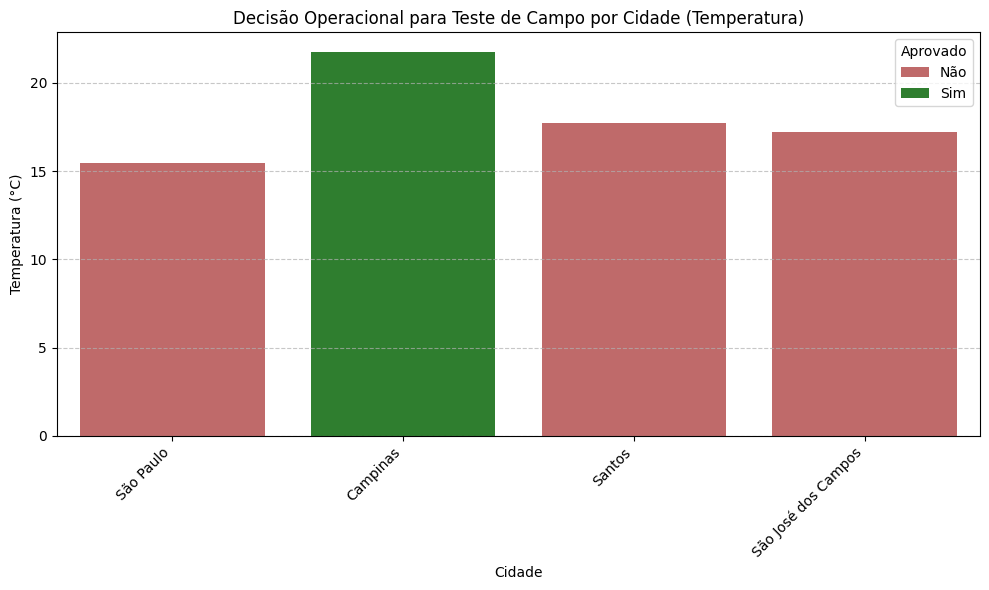

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame from dados_clima for easier plotting
df_clima = pd.DataFrame(dados_clima)

# Add an 'Aprovado' column based on cidades_aprovadas
df_clima['Aprovado'] = df_clima['cidade'].apply(lambda x: 'Sim' if x in cidades_aprovadas else 'Não')

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='cidade', y='temperatura', hue='Aprovado', data=df_clima, palette={'Sim': 'forestgreen', 'Não': 'indianred'}, dodge=False)
plt.title('Decisão Operacional para Teste de Campo por Cidade (Temperatura)')
plt.xlabel('Cidade')
plt.ylabel('Temperatura (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

O gráfico acima visualiza a temperatura de cada cidade e indica se ela foi aprovada para o teste de campo. As barras verdes representam cidades aprovadas, enquanto as vermelhas indicam cidades que não atenderam aos critérios. Você pode observar as temperaturas em relação aos limites de 18°C e 32°C.

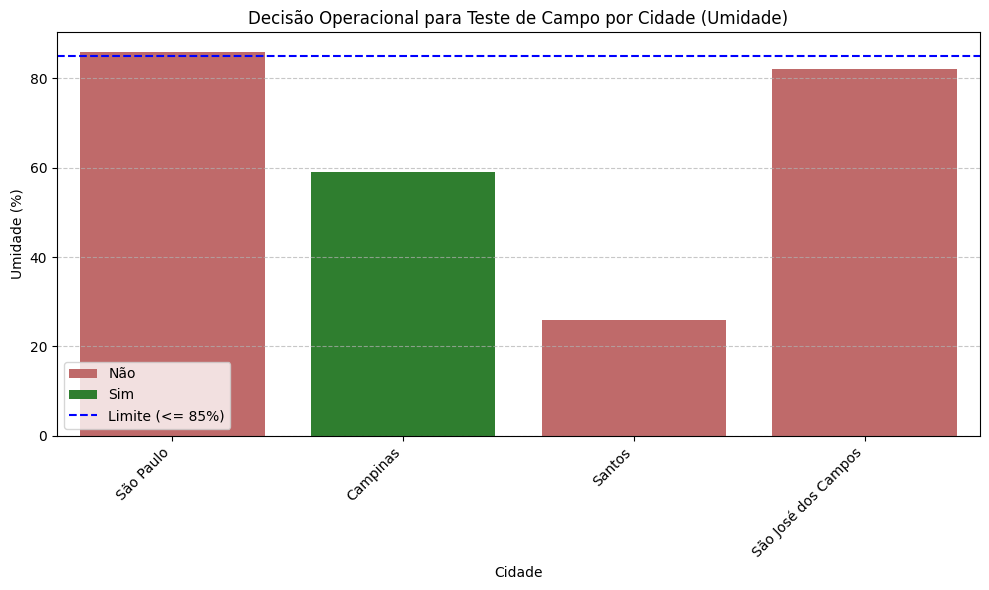

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cidade', y='umidade', hue='Aprovado', data=df_clima, palette={'Sim': 'forestgreen', 'Não': 'indianred'}, dodge=False)
plt.title('Decisão Operacional para Teste de Campo por Cidade (Umidade)')
plt.xlabel('Cidade')
plt.ylabel('Umidade (%)')
plt.axhline(y=85, color='blue', linestyle='--', label='Limite (<= 85%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Este gráfico mostra a umidade de cada cidade. A linha tracejada azul representa o limite máximo de 85% de umidade. As cidades em verde estão aprovadas, enquanto as em vermelho foram reprovadas por algum critério (não necessariamente apenas umidade).

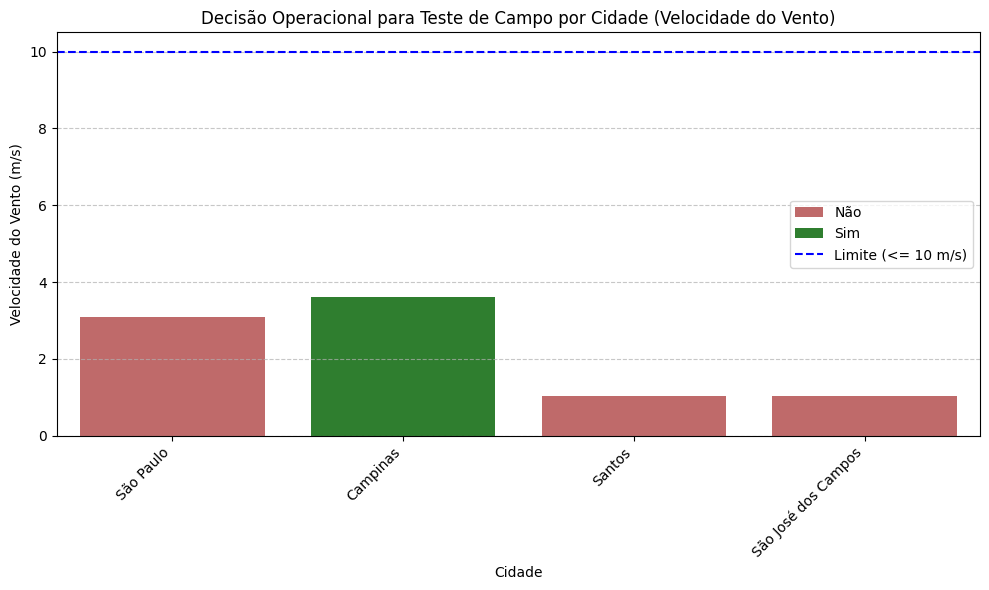

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cidade', y='vento', hue='Aprovado', data=df_clima, palette={'Sim': 'forestgreen', 'Não': 'indianred'}, dodge=False)
plt.title('Decisão Operacional para Teste de Campo por Cidade (Velocidade do Vento)')
plt.xlabel('Cidade')
plt.ylabel('Velocidade do Vento (m/s)')
plt.axhline(y=10, color='blue', linestyle='--', label='Limite (<= 10 m/s)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Por fim, este gráfico ilustra a velocidade do vento em cada cidade. A linha tracejada azul marca o limite máximo de 10 m/s. Novamente, as barras verdes indicam cidades aprovadas e as vermelhas cidades reprovadas.

---
# Critérios de avaliação

| Questão | Evidência esperada | Pontos |
|---|---|---:|
| 1 | Leitura de dicionário retornado pela API e criação de lista de tuplas | 2,0 |
| 2 | Dicionário com tuplas e integração entre estruturas | 3,0 |
| 3 | Leitura de JSON aninhado e criação de lista de dicionários | 2,0 |
| 4 | Filtragem de dados e construção de dicionário-relatório | 3,0 |
| **Total** |  | **10,0** |
